In [8]:
!pwd

/home/gott/openvino_notebooks/notebooks/Face_REG


Training completed and model saved.


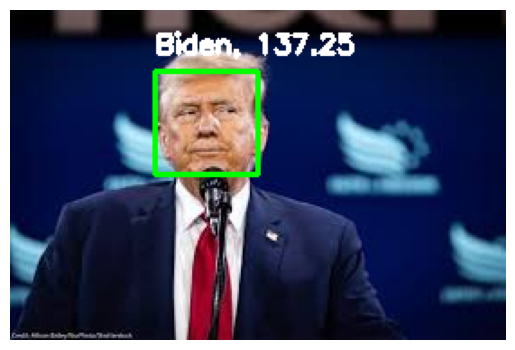

Predicted Name: Biden, Confidence: 137.25


In [62]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Load pre-trained face detection model (Haar Cascade)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Create a LBPH face recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()

# Map numeric labels to names
label_names = {
    1: "Biden",
    2: "Trump",
    # Add more mappings as needed
}

def prepare_training_data(data_folder_path):
    dirs = os.listdir(data_folder_path)
    
    faces = []
    labels = []
    
    for dir_name in dirs:
        if not dir_name.isdigit():  # Skip non-numeric directory names
            continue
        
        label = int(dir_name)
        subject_dir_path = os.path.join(data_folder_path, dir_name)
        subject_images_names = os.listdir(subject_dir_path)
        
        for image_name in subject_images_names:
            image_path = os.path.join(subject_dir_path, image_name)
            image = cv2.imread(image_path)
            gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # Apply histogram equalization for better contrast
            gray_image = cv2.equalizeHist(gray_image)

            faces_detected = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
            
            for (x, y, w, h) in faces_detected:
                faces.append(gray_image[y:y + h, x:x + w])
                labels.append(label)
    
    return faces, labels

# Train the recognizer
data_folder_path = 'dataset'  # Path to your dataset
faces, labels = prepare_training_data(data_folder_path)

if len(faces) == 0:
    print("No faces found in the training data.")
else:
    recognizer.train(faces, np.array(labels))
    recognizer.save('face_recognition_model.yml')
    print("Training completed and model saved.")

# Function to predict faces in a new image
def predict(test_image):
    gray_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
    faces_detected = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    predictions = []
    
    for (x, y, w, h) in faces_detected:
        face = gray_image[y:y + h, x:x + w]
        label, confidence = recognizer.predict(face)
        
        # Set a confidence threshold for prediction reliability
        if confidence < 100:  # You can adjust this threshold
            name = label_names.get(label, "Unknown")  # Default to "Unknown"
            predictions.append((name, confidence))
            
            # Draw rectangle around the face and put name
            cv2.rectangle(test_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            text = f'{name}, {confidence:.2f}'
            cv2.putText(test_image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        else:
            cv2.rectangle(test_image, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Red box for low confidence
            cv2.putText(test_image, "Unknown", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    return test_image, predictions

# Test the recognizer with a new image
test_image_path = 'testIMG/test2.jpeg'  # Update this path
test_image = cv2.imread(test_image_path)

if test_image is not None:
    predicted_image, predictions = predict(test_image)
    
    # Show the predicted image with labels
    plt.imshow(cv2.cvtColor(predicted_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    # Print the results
    for name, confidence in predictions:
        print(f'Predicted Name: {name}, Confidence: {confidence:.2f}')
else:
    print("Error: Could not read the test image. Check the file path.")


retry for old code

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Load pre-trained face detection model (Haar Cascade)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Create a LBPH face recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()

# Map numeric labels to names
label_names = {
    1: "Biden",
    2: "Trump",
    # Add more mappings as needed
}

def prepare_training_data(data_folder_path, image_size=(200, 200)):
    dirs = os.listdir(data_folder_path)
    
    faces = []
    labels = []
    
    for dir_name in dirs:
        if not dir_name.isdigit():  # Skip non-numeric directory names
            continue
        
        label = int(dir_name)
        subject_dir_path = os.path.join(data_folder_path, dir_name)
        subject_images_names = os.listdir(subject_dir_path)
        
        for image_name in subject_images_names:
            # Skip hidden files (those starting with a dot)
            if image_name.startswith('.'):
                print(f"Skipping hidden file: {image_name}")
                continue
            
            print(f"Found file: {image_name}")  # Debugging line
            image_path = os.path.join(subject_dir_path, image_name)
            
            try:
                image = cv2.imread(image_path)
                
                # Check if the image was loaded successfully
                if image is None:
                    print(f"Warning: Could not read image at {image_path}. Skipping this file.")
                    continue
                
                gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Apply histogram equalization for better contrast
                gray_image = cv2.equalizeHist(gray_image)
                
                # Resize image to a consistent size
                gray_image = cv2.resize(gray_image, image_size)

                faces_detected = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
                
                for (x, y, w, h) in faces_detected:
                    faces.append(gray_image[y:y + h, x:x + w])
                    labels.append(label)
            except Exception as e:
                print(f"Error reading image at {image_path}: {e}")

    return faces, labels



# Train the recognizer
data_folder_path = 'dataset'  # Path to your dataset
faces, labels = prepare_training_data(data_folder_path, image_size=(200, 200))

if len(faces) == 0:
    print("No faces found in the training data.")
else:
    recognizer.train(faces, np.array(labels))
    recognizer.save('face_recognition_model.yml')
    print("Training completed and model saved.")

def predict(test_image):
    gray_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
    faces_detected = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    predictions = []
    
    for (x, y, w, h) in faces_detected:
        face = gray_image[y:y + h, x:x + w]
        
        # Optional: Show the detected face
        cv2.imshow("Detected Face", face)
        cv2.waitKey(0)  # Wait for a key press to view the face
        cv2.destroyAllWindows()
        
        # Resize and preprocess the face
        face = cv2.equalizeHist(face)
        face = cv2.resize(face, (200, 200))  # Resize to match training data

        label, confidence = recognizer.predict(face)
        
        # Get the name from the label
        name = label_names.get(label, "Unknown")
        
        # Draw rectangle around the face and put name
        cv2.rectangle(test_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        text = f'{name}, {confidence:.2f}'
        cv2.putText(test_image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        predictions.append((name, confidence))
    
    return test_image, predictions

# Test the recognizer with a new image
test_image_path = 'testIMG/test2.jpeg'  # Update this path
test_image = cv2.imread(test_image_path)

if test_image is not None:
    predicted_image, predictions = predict(test_image)
    
    # Show the predicted image with labels
    plt.imshow(cv2.cvtColor(predicted_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    # Print the results
    for name, confidence in predictions:
        print(f'Predicted Name: {name}, Confidence: {confidence:.2f}')
else:
    print("Error: Could not read the test image. Check the file path.")


# New model

In [51]:
import cv2
import numpy as np
import math
import time
import collections
from PIL import Image
from pathlib import Path
import tarfile

import openvino as ov
from IPython import display
import copy

In [53]:
# Import local modules

if not Path("./notebook_utils.py").exists():
    # Fetch `notebook_utils` module
    import requests

    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)
import notebook_utils as utils

In [55]:
device = utils.device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [54]:
# Define the function to download text detection and recognition models from PaddleOCR resources.


def run_model_download(model_url: str, model_file_path: Path) -> None:
    """
    Download pre-trained models from PaddleOCR resources

    Parameters:
        model_url: url link to pre-trained models
        model_file_path: file path to store the downloaded model
    """
    archive_path = model_file_path.absolute().parent.parent / model_url.split("/")[-1]
    if model_file_path.is_file():
        print("Model already exists")
    else:
        # Download the model from the server, and untar it.
        print("Downloading the pre-trained model... May take a while...")

        # Create a directory.
        utils.download_file(model_url, archive_path.name, archive_path.parent)
        print("Model Downloaded")

        file = tarfile.open(archive_path)
        res = file.extractall(archive_path.parent)
        file.close()
        if not res:
            print(f"Model Extracted to {model_file_path}.")
        else:
            print("Error Extracting the model. Please check the network.")

In [56]:
# Define the function to download text detection and recognition models from PaddleOCR resources.


def run_model_download(model_url: str, model_file_path: Path) -> None:
    """
    Download pre-trained models from PaddleOCR resources

    Parameters:
        model_url: url link to pre-trained models
        model_file_path: file path to store the downloaded model
    """
    archive_path = model_file_path.absolute().parent.parent / model_url.split("/")[-1]
    if model_file_path.is_file():
        print("Model already exists")
    else:
        # Download the model from the server, and untar it.
        print("Downloading the pre-trained model... May take a while...")

        # Create a directory.
        utils.download_file(model_url, archive_path.name, archive_path.parent)
        print("Model Downloaded")

        file = tarfile.open(archive_path)
        res = file.extractall(archive_path.parent)
        file.close()
        if not res:
            print(f"Model Extracted to {model_file_path}.")
        else:
            print("Error Extracting the model. Please check the network.")

In [59]:
import requests
from pathlib import Path
import tarfile
import zipfile
import os

def run_model_download(model_url, model_file_path):
    # Ensure the directory exists
    model_file_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Download the model
    print(f"Downloading model from {model_url}...")
    response = requests.get(model_url)
    
    if response.status_code == 200:
        with open(model_file_path, 'wb') as f:
            f.write(response.content)
        print("Model downloaded successfully.")
        
        # Check file extension and extract accordingly
        if model_file_path.suffix == '.tar':
            try:
                with tarfile.open(model_file_path) as tar:
                    tar.extractall(path=model_file_path.parent)
                print("Model extracted successfully.")
            except tarfile.TarError as e:
                print(f"Error extracting the tar file: {e}")
        elif model_file_path.suffix == '.zip':
            try:
                with zipfile.ZipFile(model_file_path, 'r') as zip_ref:
                    zip_ref.extractall(model_file_path.parent)
                print("Model extracted successfully.")
            except zipfile.BadZipFile as e:
                print(f"Error extracting the zip file: {e}")
        else:
            print("The downloaded file is not a supported archive format.")
    else:
        print(f"Failed to download the model. Status code: {response.status_code}")

# URL for the face detection model (update to zip format if needed)
face_model_url = "https://storage.openvinotoolkit.org/repositories/open_model_zoo/face-detection-0200/FP32/face-detection-0200.tar"
face_model_file_path = Path("model/face-detection-0200.tar")

# Download the face detection model
run_model_download(face_model_url, face_model_file_path)


Model downloaded successfully.
Error extracting the tar file: file could not be opened successfully:
- method gz: ReadError('not a gzip file')
- method bz2: ReadError('not a bzip2 file')
- method xz: ReadError('not an lzma file')
- method tar: ReadError('invalid header')
